In [ ]:
# os.chdir("hmr4d/")
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '1,'
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
from einops import einsum
import cv2
from PIL import Image
import lovely_tensors as lt
lt.monkey_patch()
import imageio.v3 as iio
import torch
from smplx.joint_names import JOINT_NAMES, SMPLH_JOINT_NAMES

from hydra import compose, initialize_config_module
from hydra.utils import instantiate

from hmr4d.configs import register_store_gvhmr
from hmr4d.network.gvhmr.relative_transformer import NetworkEncoderRoPEwithCA
from hmr4d.model.gvhmr.utils.endecoder import EnDecoder
from hmr4d.model.gvhmr.pipeline.gvhmr_pipeline import get_smpl_params_w_Rt_v2
from hmr4d.model.gvhmr.utils.postprocess import (
    pp_static_joint,
    process_ik,
    pp_static_joint_cam,
)
from hmr4d.dataset.threedpw.threedpw_motion_test import ThreedpwSmplFullSeqDataset
from hmr4d.utils.preproc import Tracker, Extractor, VitPoseExtractor, SimpleVO
from hmr4d.utils.preproc.vitpose_pytorch.src.vitpose_infer.pose_utils.pose_viz import joints_dict
from hmr4d.utils.geo.hmr_cam import estimate_K, create_camera_sensor
from hmr4d.utils.geo.hmr_cam import compute_bbox_info_bedlam, compute_transl_full_cam, normalize_kp2d
from hmr4d.utils.geo_transform import apply_T_on_points, compute_T_ayfz2ay, compute_cam_angvel, move_to_start_point_face_z
from hmr4d.utils.body_model import BodyModelSMPLH, BodyModelSMPLX
from hmr4d.utils.body_model.smplx_lite import SmplxLiteV437Coco17
from hmr4d.utils.video_io_utils import get_writer
from hmr4d.utils.vis.renderer import Renderer, get_global_cameras_static, get_ground_params_from_points
from hmr4d.utils.vis.cv2_utils import draw_bbx_xyxy_on_image_batch, draw_bbx_xys_on_image_batch, draw_kpts_with_conf_batch, draw_kpts_batch
from hmr4d.utils.vis.plot_vis import plot_angle_changes

device = 'cuda'

In [ ]:
smpl = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="neutral", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).cuda()
smplx = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="neutral", num_pca_comps=12, flat_hand_mean=False,
).cuda()
smplx_coco = SmplxLiteV437Coco17().cuda()
smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").cuda()
faces_smpl = smpl.faces
J_regressor = torch.load("hmr4d/utils/body_model/smpl_neutral_J_regressor.pt").cuda()

/tmp/ipykernel_1052869/643882862.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").cuda()
/tmp/ipyk

In [15]:

def to_device(x):
    if isinstance(x, torch.Tensor):
        return x.to(device)
    if isinstance(x, dict):
        return {k: to_device(v) for k, v in x.items()}
    return x

def make_K_crop(K_full, bbx, crop_size):
    # bbx = [cx, cy, size]
    K = K_full.clone().float()
    cx_b, cy_b, s = bbx[0].float(), bbx[1].float(), bbx[2].float()
    hs = torch.clamp(0.5 * s, min=1e-6)
    scale = (crop_size - 1) / (2.0 * hs)

    fx = K[0, 0] * scale
    fy = K[1, 1] * scale
    cx = (K[0, 2] - (cx_b - hs)) * scale
    cy = (K[1, 2] - (cy_b - hs)) * scale

    Kc = torch.zeros((3, 3), dtype=K.dtype, device=K.device)
    Kc[0, 0] = fx
    Kc[1, 1] = fy
    Kc[0, 2] = cx
    Kc[1, 2] = cy
    Kc[2, 2] = 1.0
    return Kc

def map_kp2d_to_crop(kp2d_full, bbx, crop_size):
    # kp2d_full: (J,2 or 3) in full-image coords
    kp = kp2d_full.clone().float()
    x, y = kp[:, 0], kp[:, 1]
    cx, cy, s = bbx[0].float(), bbx[1].float(), bbx[2].float()
    hs = torch.clamp(0.5 * s, min=1e-6)
    x0, y0 = cx - hs, cy - hs
    scale = (crop_size - 1) / (2.0 * hs)
    kp[:, 0] = (x - x0) * scale
    kp[:, 1] = (y - y0) * scale
    return kp

def get_frame_index_for_image(sample, img_slot=0):
    idx = sample.get('image_frame_indices', None)
    if idx is None or len(idx) == 0:
        return 0
    return int(idx[img_slot].item())

def select_smpl_params_at(params_dict, t):
    out = {}
    for k, v in params_dict.items():
        if isinstance(v, torch.Tensor) and v.dim() >= 2:
            out[k] = v[t:t+1]
        else:
            out[k] = v
    return out

def render_smpl_on_crop(sample, img_slot=0):
    if sample.get('image', None) is None:
        return None, None
    if sample['image'].shape[0] == 0:
        return None, None

    frame_t = get_frame_index_for_image(sample, img_slot=img_slot)
    crop = sample['image'][img_slot].cpu().numpy().astype(np.uint8)
    H, W = crop.shape[:2]

    bbx = sample['bbx_xys'][frame_t]
    K_full = sample['K_fullimg'][frame_t]
    K_crop = make_K_crop(K_full.to(device), bbx.to(device), H)

    cam_render = None
    world_render = None
    with torch.no_grad():

        if 'smpl_params' in sample and sample['smpl_params'] is not None:
            sp = select_smpl_params_at(sample['smpl_params'], frame_t)
            sp = {k: v.to(device) for k, v in sp.items()}
            verts_c = smpl(**sp).vertices[0]            
            verts_c = apply_T_on_points(verts_c, sample["T_w2c"][frame_t].to(device))
            renderer = Renderer(W, H, device=str(device), faces=smpl.faces, K=K_crop.detach())
            cam_render = renderer.render_mesh(verts_c, background=crop.copy())
            
        if 'smpl_params_c' in sample and sample['smpl_params_c'] is not None:
            sp_c = select_smpl_params_at(sample['smpl_params_c'], frame_t)
            sp_c = {k: v.to(device) for k, v in sp_c.items()}
            verts_c = smplx(**sp_c).vertices[0]
            verts_c  = torch.matmul(smplx2smpl, verts_c)
            
            renderer = Renderer(W, H, device=str(device), faces=smpl.faces, K=K_crop.detach())
            cam_render = renderer.render_mesh(verts_c, background=crop.copy())

        # world render: canonicalized world vertices rendered in a simple preview camera
        if 'smpl_params_w' in sample and sample['smpl_params_w'] is not None and sample['smpl_params_w']['body_pose'].sum().item() != 0:
            sp_w = select_smpl_params_at(sample['smpl_params_w'], frame_t)
            sp_w = {k: v.to(device) for k, v in sp_w.items()}
            verts_w = smplx(**sp_w).vertices
            verts_w = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in verts_w])
            
            offset = einsum(J_regressor, verts_w[0], "j v, v i -> j i")[0]  # (3)
            offset[1] = verts_w[:, :, [1]].min()
            verts_w = verts_w - offset
            T_ay2ayfz = compute_T_ayfz2ay(einsum(J_regressor, verts_w[[0]], "j v, l v i -> l j i"), inverse=True)
            verts_w = apply_T_on_points(verts_w, T_ay2ayfz)
            joints = einsum(J_regressor, verts_w, "j v, l v i -> l j i")
            
            global_R, global_T, global_lights = get_global_cameras_static(
                verts_w.cpu(), beta=2.0, cam_height_degree=20, target_center_height=1.0, vec_rot=0,
            )
            _, _, K = create_camera_sensor(W, H, 24)
            
            renderer_w = Renderer(W, H, device=str(device), faces=smpl.faces, K=K.detach())
            scale, cx, cz = get_ground_params_from_points(joints[:, 0], verts_w)
            renderer_w.set_ground(scale * 1.5, cx, cz)
            color = torch.ones(3).float().cuda() * 0.8
            cameras = renderer_w.create_camera(global_R[0], global_T[0])
            world_render = renderer_w.render_with_ground(verts_w, color[None], cameras, global_lights)

    return cam_render, world_render

def overlay_bbx_kpts_on_crop(sample, img_slot=0):
    if sample.get('image', None) is None:
        return None
    if sample['image'].shape[0] == 0:
        return None

    frame_t = get_frame_index_for_image(sample, img_slot=img_slot)
    crop = sample['image'][img_slot].cpu().numpy().astype(np.uint8)
    H, W = crop.shape[:2]

    # In crop space, bbox is effectively full crop after crop_and_resize
    bbx_crop = torch.tensor([[W / 2.0, H / 2.0, float(min(W, H))]], dtype=torch.float32)
    vis = draw_bbx_xys_on_image_batch(bbx_crop, [crop], thickness=2)[0]

    if 'kp2d' in sample and sample['kp2d'] is not None and sample['kp2d'].shape[0] > frame_t:
        kp_full = sample['kp2d'][frame_t]
        bbx = sample['bbx_xys'][frame_t]
        kp_crop = map_kp2d_to_crop(kp_full, bbx, H)
        if kp_crop.shape[-1] >= 3:
            conf = kp_crop[:, 2:3].clamp(0, 1)
            vis = draw_kpts_with_conf_batch([vis], kp_crop[:, :2][None], conf[None], thickness=2)[0]
        else:
            conf = torch.ones((kp_crop.shape[0], 1), dtype=torch.float32)
            vis = draw_kpts_with_conf_batch([vis], kp_crop[:, :2][None], conf[None], thickness=2)[0]

    return vis

In [3]:
ds = ThreedpwSmplFullSeqDataset(load_image=True, load_indices=[0, -1])

[02/16 10:24:04][INFO] [3DPW] Full sequence
/home/guangyu/patrick/GVHMR/hmr4d/dataset/threedpw/threedpw_motion_test.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self

In [4]:
with initialize_config_module(version_base='1.3', config_module='hmr4d.configs'):
    register_store_gvhmr()
    cfg = compose(config_name='train', overrides=['exp=gvhmr/test/test_dinov3'])

model = instantiate(cfg.model, _recursive_=False).eval().to('cuda')
model.load_pretrained_model("training_results/mocap_mixed_v2_ca_dinov3/crossattn_v4/checkpoints/e099-s037700.ckpt")

print('denoiser =', type(model.pipeline.denoiser3d).__name__)
print('dinov3_pool =', model.pipeline.dinov3_pool)

/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/pipeline/gvhmr_pipeline_dinov3.py:532: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
[02/16 10:24:06][INFO] [EnDecoder] Use MM_V1_AMASS_LOCAL_BEDLAM_CAM for statistics!
[02/16 10:24:08][INFO] using base=100 for rope new
[02/16 10:24:08][INFO] using min_period=None for rope new
[02/16 10:24:08][INFO] using max_period=None for rope new
[02/16 10:24:08][INFO] using normalize_coords=separate for rope new
[02/16 10:24:08][INFO] using shift_coords=None for rope new
[02/16 10:24:08][INFO] using rescale_coords=2 for rope new
[02/16 10:24:08][INFO] using jitter_coords=None for rope new
[02/16 10:24:08][INFO] using dtype=fp32 for rope new
[02/16 10:24:08][INFO] using swiglu layer as FFN
[02/16 10:24:24][INFO] [PL-Trainer] Loading ckpt: training_results/mocap_mixed_v2_ca_dinov3/crossattn_v4/checkpoints/e099-s037700.ckpt
/home/guangyu/patrick/GVHMR/h

denoiser = NetworkEncoderRoPEwithCA
dinov3_pool = mean


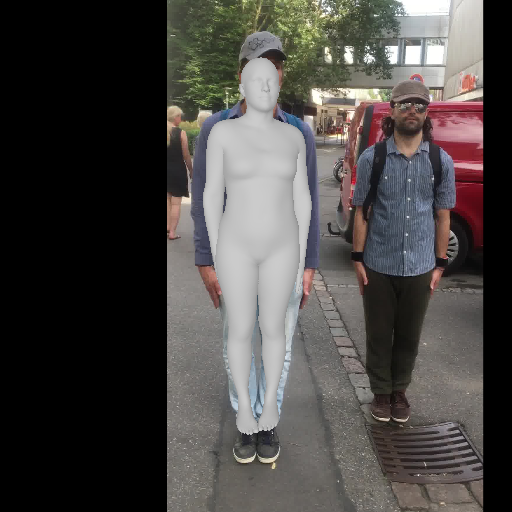

In [21]:
batch = ds[0]

slot = 0
overlay = overlay_bbx_kpts_on_crop(batch, img_slot=slot)
cam_render, world_render = render_smpl_on_crop(batch, img_slot=slot)
Image.fromarray(cam_render)

### 3. Model Inference

In [36]:
cliff_cam = compute_bbox_info_bedlam(bbx_xys[None], K_fullimg[None]).to('cuda')  # (B, L, 3)
f_cam_angvel = compute_cam_angvel(R_w2c).to('cuda')
f_condition = {
    "obs": normalize_kp2d(vitpose, bbx_xys)[None].to('cuda'),  # (B, L, J, 3)
    "f_cliffcam": cliff_cam,  # (B, L, 3)
    "f_cam_angvel": (f_cam_angvel - cam_angvel_mean) / cam_angvel_std,  # (B, L, C=6)
    "f_imgseq": vit_features_hmr[None].to('cuda'),  # (B, L, C=1024)
    "f_dino_imgseq" : vit_features_dino[[0,-1]][None].to('cuda'),  # (B, L, C=1024)
    "f_dino_frame" : torch.tensor([0, length-1], device='cuda')[None],  # (B, L)
    # "f_imgseq": torch.zeros_like(vit_features)[None].to('cuda')
}

with torch.no_grad():
    model_output = denoiser3d(length=torch.tensor([length], device='cuda'), **f_condition)  # pred_x, pred_cam, static_conf_logits
    decode_dict = endecoder.decode(model_output["pred_x"]) 

In [37]:
outputs = {}
# Post-processing
outputs["pred_smpl_params_incam"] = {
    "body_pose": decode_dict["body_pose"],  # (B, L, 63)
    "betas": decode_dict["betas"],  # (B, L, 10)
    "global_orient": decode_dict["global_orient"],  # (B, L, 3)
    "transl": compute_transl_full_cam(
        model_output["pred_cam"], bbx_xys.to('cuda'), K_fullimg.to('cuda')),
}

pred_smpl_params_global = get_smpl_params_w_Rt_v2(  # This function has for-loop
    global_orient_gv=decode_dict["global_orient_gv"],
    local_transl_vel=decode_dict["local_transl_vel"],
    global_orient_c=decode_dict["global_orient"],
    cam_angvel=f_cam_angvel[None],
)
outputs["pred_smpl_params_global"] = {
    "body_pose": decode_dict["body_pose"],
    "betas": decode_dict["betas"],
    **pred_smpl_params_global,
}
outputs["static_conf_logits"] = model_output["static_conf_logits"]

if static_cam:  # extra post-processing to utilize static camera prior
    outputs["pred_smpl_params_global"]["transl"] = pp_static_joint_cam(outputs, endecoder)
else:
    outputs["pred_smpl_params_global"]["transl"] = pp_static_joint(outputs, endecoder)

body_pose = process_ik(outputs, endecoder)
decode_dict["body_pose"] = body_pose
outputs["pred_smpl_params_global"]["body_pose"] = body_pose
outputs["pred_smpl_params_incam"]["body_pose"] = body_pose

pred = {
    "smpl_params_global": {k: v[0] for k, v in outputs["pred_smpl_params_global"].items()},
    "smpl_params_incam": {k: v[0] for k, v in outputs["pred_smpl_params_incam"].items()},
}

final_results = {
    "input_video" : str(video_path.absolute()),
    'model_dir': str(model_dir.absolute()),
    "dimensions" : (length, width, height),
    "bbx_xyxy": bbx_xyxy, "bbx_xys": bbx_xys,
    "vitpose": vitpose,
    'vit_features_hmr': vit_features_hmr,
    'vit_features_dino': vit_features_dino,
    'vo_results': vo_results,
    'K_fullimg': K_fullimg,
    'smpl_params_global' :pred["smpl_params_global"],
    'smpl_params_incam' :pred["smpl_params_incam"],
    'static_conf_logits': outputs['static_conf_logits'][0], 
}
# torch.save(final_results, output_root / f"{video_path.stem}.pt")

### 4. Render InCamera View

In [38]:
# smpl
length, width, height = final_results['dimensions']
r_width, r_height = width, height # 
# final_results = torch.load(output_root / f"{video_path.stem}.pt")
# length, width, height = final_results['dimensions']
# plot_angle_changes(final_results["smpl_params_global"]['global_orient'])

renderer_c = Renderer(r_width, r_height, device="cuda", faces=faces_smpl, K=estimate_K(r_width, r_height))

smplx_c = smplx(**final_results["smpl_params_incam"])
pred_c_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smplx_c.vertices])
pred_c_joints, pred_c_valid = renderer_c.project_points_to_full_image(smplx_c.joints)

smplx_gb = smplx(**final_results["smpl_params_global"])
pred_gb_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smplx_gb.vertices])
pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(pred_gb_verts, J_regressor)

global_R, global_T, global_lights = get_global_cameras_static(
    pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
)
_, _, K = create_camera_sensor(r_width, r_height, 24)
renderer_g = Renderer(r_width, r_height, device="cuda", faces=faces_smpl, K=K)

# -- render mesh -- #
scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
renderer_g.set_ground(scale * 1.5, cx, cz)
color = torch.ones(3).float().cuda() * 0.8

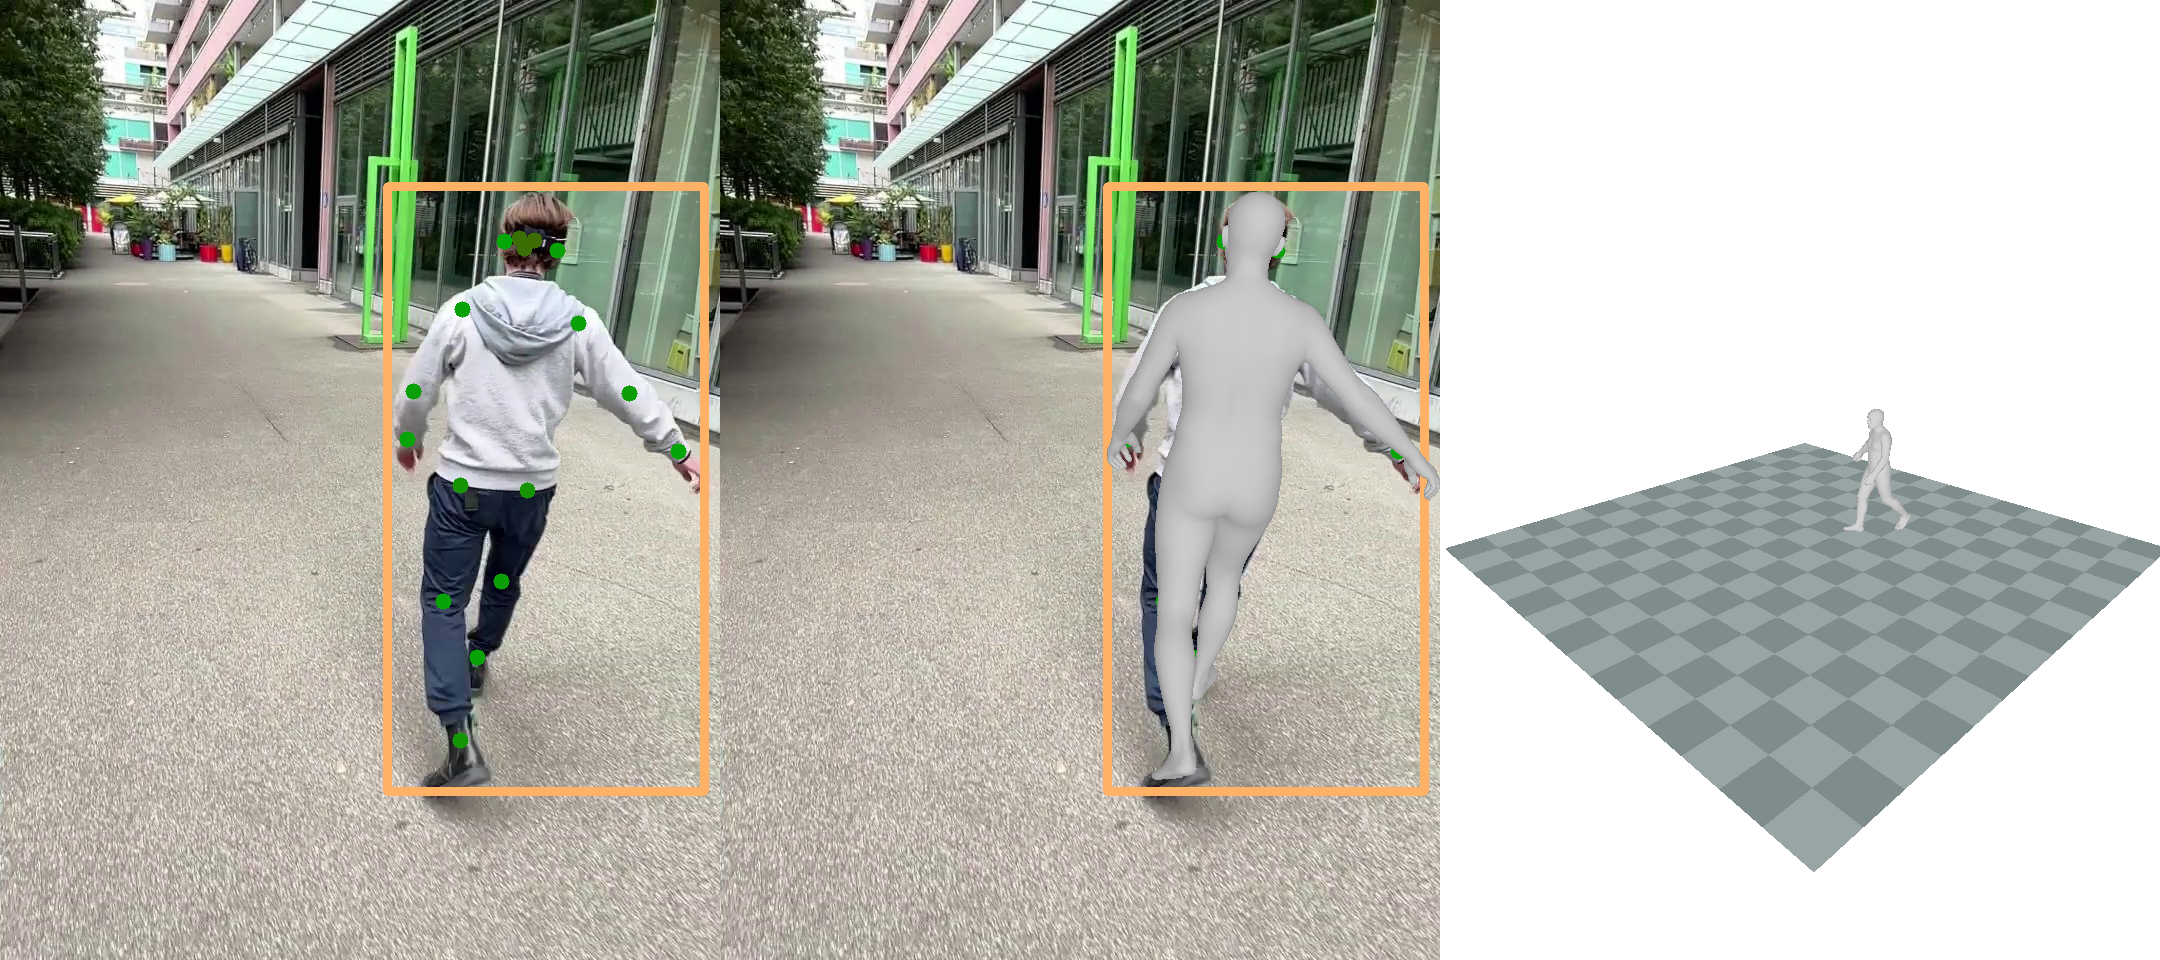

In [40]:
i = 25

img_raw = cv2.resize(iio.imread(final_results['input_video'], index=i), (width, height))
img_raw = draw_bbx_xyxy_on_image_batch(final_results['bbx_xyxy'][i:i+1], [img_raw], thickness=8)[0]
img_raw = draw_kpts_with_conf_batch(
    [img_raw[..., ::-1]], final_results['vitpose'][i:i+1, ..., :2], 
                            final_results['vitpose'][i:i+1, ...,  2], thickness=8)[0][...,::-1]
img_raw = cv2.resize(img_raw, (r_width, r_height))

img_cam = renderer_c.render_mesh(pred_c_verts[i].cuda(), img_raw, colors=[0.8, 0.8, 0.8])
# img_cam = draw_kpts_with_conf_batch([img_cam], pred_c_joints[i:i+1][:,:-98], pred_c_valid[i:i+1][:,:-98], thickness=4)[0]

cameras = renderer_g.create_camera(global_R[i], global_T[i])
img_gb = renderer_g.render_with_ground(pred_gb_verts[[i]], color[None], cameras, global_lights)

Image.fromarray(np.concatenate([img_raw, img_cam, img_gb], axis=1))

In [41]:
# writer = get_writer(output_root / f'og-{video_path.stem}.mp4', fps=10, crf=23)
writer = get_writer(f'tmp.mp4', fps=30, crf=23)
for i in tqdm(range(length), desc=f"Rendering Global"):
    img_raw = cv2.resize(iio.imread(final_results['input_video'], index=i), (r_width, r_height))
    img_raw = draw_bbx_xyxy_on_image_batch(final_results['bbx_xyxy'][i:i+1], [img_raw], thickness=8)[0]
    # img_raw = draw_kpts_with_conf_batch([img_raw], pred_c_joints[i:i+1], pred_c_valid[i:i+1], thickness=4)[0]

    img_cam = renderer_c.render_mesh(pred_c_verts[i].cuda(), img_raw, colors=[0.8, 0.8, 0.8])
    # img_cam = draw_kpts_with_conf_batch([img_cam], pred_c_joints[i:i+1], pred_c_valid[i:i+1], thickness=4)[0]

    cameras = renderer_g.create_camera(global_R[i], global_T[i])
    img_gb = renderer_g.render_with_ground(pred_gb_verts[[i]], color[None], cameras, global_lights)
    img = np.concatenate([img_raw, img_cam, img_gb], axis=1)
    writer.write_frame(img)
writer.close()

Rendering Global: 100%|██████████| 120/120 [02:17<00:00,  1.14s/it]


In [ ]:
# from hmr4d.utils.vis.renderer import overlay_image_onto_background

# i = 250

# cameras = renderer_g.create_camera(global_R[i], global_T[i])
# img_gb = renderer_g.render_with_ground(pred_gb_verts[[i]], color[None], cameras, global_lights)

# frust_verts_cam, frust_faces = frustum_vertices_in_camera(K.cuda(), W=r_width, H=r_height, z_near=1.0)
# frust_verts_wld = camera_to_world_points(frust_verts_cam, R_cw=R_cw_all[i], t_cw=t_cw_all[i,...,0])

# vertices=frust_verts_wld.to('cuda')
# faces=frust_faces.unsqueeze(0).to('cuda')
# background=img_gb
# colors=[0.0, 0.8, 0.8]
# update_bbox=False
# flip=False

# if update_bbox:
#     renderer_g.update_bbox(vertices[::50], scale=1.2)
# vertices = vertices.unsqueeze(0)

# if isinstance(colors, torch.Tensor):
#     # per-vertex color
#     verts_features = colors.to(device=vertices.device, dtype=vertices.dtype)
#     colors = [0.8, 0.8, 0.8]
# else:
#     if colors[0] > 1:
#         colors = [c / 255.0 for c in colors]
#     verts_features = torch.tensor(colors).reshape(1, 1, 3).to(device=vertices.device, dtype=vertices.dtype)
#     verts_features = verts_features.repeat(1, vertices.shape[1], 1)
# textures = TexturesVertex(verts_features=verts_features)

# if faces is None:
#     faces = renderer_g.faces
# mesh = Meshes(verts=vertices, faces=faces, textures=textures)

# materials = Materials(device=renderer_g.device, specular_color=(colors,), shininess=0)

# results = renderer_g.renderer(mesh, materials=materials, cameras=renderer_g.cameras, lights=renderer_g.lights)
# if flip:
#     results = torch.flip(results, [1, 2])
# image = results[0, ..., :3] * 255
# mask = results[0, ..., -1] > 1e-3

# if background is None:
#     background = np.ones((renderer_g.height, renderer_g.width, 3)).astype(np.uint8) * 255
    
# if update_bbox:
#     bbox = renderer_g.bboxes
# else:
#     bbox = torch.tensor([[0, 0, renderer_g.width, renderer_g.height]]).float().to(renderer_g.device)

# image = overlay_image_onto_background(image, mask, bbox, background.copy())
# renderer_g.reset_bbox()

# Image.fromarray(image)

In [ ]:
# from einops import einsum
# from hmr4d.utils.geo_transform import kabsch_algorithm_batch

# tmp_pred_c_joints = einsum(J_regressor, pred_c_verts, "j v, l v i -> l j i")

# R_cw_all = []
# t_cw_all = []
# for Xc, Xw in zip(tmp_pred_c_joints, pred_gb_joints):
#     R, t = kabsch_algorithm_batch(Xw, Xc)
#     R_cw_all.append(R)
#     t_cw_all.append(t)
# R_cw_all = torch.stack(R_cw_all, dim=0)
# t_cw_all = torch.stack(t_cw_all, dim=0)

# # from pytorch3d.transforms import axis_angle_to_matrix

# # R_cb = axis_angle_to_matrix(final_results["smpl_params_incam"]['global_orient'])
# # t_cb = final_results["smpl_params_incam"]['transl']

# # R_wb = axis_angle_to_matrix(final_results["smpl_params_global"]['global_orient'])
# # t_wb = final_results["smpl_params_global"]['transl']

# # R_cw_all = R_cb @ R_wb.transpose(-1, -2)                # (T,3,3)
# # t_cw_all = t_cb - (R_cw_all @ t_wb.unsqueeze(-1)).squeeze(-1)  # (T,3)

# # R_wc_all = R_cw_all.transpose(-1, -2)
# # t_wc_all = t_wb - (R_wc_all @ t_cb.unsqueeze(-1)).squeeze(-1)

# frust_verts_cam, frust_faces = frustum_vertices_in_camera(K.cuda(), W=r_width, H=r_height, offset_z=2.0)

In [ ]:
# # frust_verts_wld = camera_to_world_points(frust_verts_cam, R_cw=R_cw_all[i], t_cw=t_cw_all[i,...,0])
# frust_verts_wld = (R_cw_all[i].T @ (frust_verts_cam - t_cw_all[i,...][None]).T).T
# img_gb = renderer_g.render_mesh(
#     frust_verts_wld.to('cuda'), 
#     faces=frust_faces.unsqueeze(0).to('cuda'), 
#     background=img_gb, 
#     colors=[0.0, 0.8, 0.8], update_bbox=False, flip=True
# )